# Lego Assembly

Should setup environment, planner etc like in exercises and show results 

In [1]:
%matplotlib inline
import time, functools
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from tampanda import ArmSceneBuilder, RRTStar, GraspPlanner, PickPlaceExecutor
from tampanda.scenes import TABLE_SYMBOLIC_TEMPLATE, BLOCK_SMALL_TEMPLATE
from tampanda.tamp import DomainBridge
from tampanda.symbolic.domains.blocks.blocks_domain import BlocksDomain
from tampanda.planners.grasp_planner import GraspType, GRASP_CONTACT_OFFSET

print("Imports OK ✓")

Matplotlib is building the font cache; this may take a moment.


Imports OK ✓


In [3]:
from pathlib import Path
print(Path("lego_coarse.pddl").read_text())

(define (domain lego-coarse)
  (:requirements :strips :typing :existential-preconditions)

  (:types
    ; item
    ; location
    ; grasp-config

    dim
    brick
    color
    location
  )

  (:predicates
    (shape ?b - brick ?d - dim)
    (is ?b - brick ?c - color)
    (at ?b - brick ?l - location)
    (stacked_on ?a - brick ?b - brick)
    (clear ?l - location)

    ; (config-for ?c - grasp-config ?o - brick) ; static: c is a candidate grasp for o
    ; (ik-feasible ?c - grasp-config)           ; geometric: grasp c is collision-free (sensed)
    ; (accessible ?o - brick)                   ; geometric: o has >=1 feasible grasp (sensed)
    ; (obstructs ?a - brick ?b - brick)         ; geometric: a blocks b's approach (sensed)
    ; (holding ?b - brick ?c - grasp-config)

    (holding ?b - brick)
    (hand-empty)
  )

  (:action pick
    :parameters (?b - brick ?from - location)
    :precondition (and
      (at ?b ?from)
      (hand-empty)
    )
    :effect (and
      (not (at ?b ?

In [9]:
builder = ArmSceneBuilder()
builder.add_resource("table", TABLE_SYMBOLIC_TEMPLATE)
builder.add_resource("block", BLOCK_SMALL_TEMPLATE)
builder.add_object("table", name="table", pos=[0.0, 0.4, 0.0], quat=[0.0, 0.0, 0.0, 1.0])

builder.add_object("block", name="block_0", pos=[0.500, 0.500, 0.300], quat=[0.0, 0.0, 0.0, 1.0])
builder.add_object("block", name="block_1", pos=[0.900, 0.000, 0.300], quat=[0.0, 0.0, 0.0, 1.0])
builder.add_object("block", name="block_2", pos=[0.200, 0.500, 0.300], quat=[0.0, 0.0, 0.0, 1.0])
env = builder.build_env(rate=200.0)

In [7]:
# ── Visualisation helpers (provided) ──────────────────────────────────────────
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam
def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img
def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)
def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()
def _table_center():
    try: return ((BOUNDS["min_x"]+BOUNDS["max_x"])/2, (BOUNDS["min_y"]+BOUNDS["max_y"])/2, BOUNDS["table_height"])
    except NameError: return (0.4, 0.4, 0.27)
def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25):
    _show(_render(env, _free_cam(env, _table_center(), distance, azimuth, elevation)), title)
def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center(), distance, 90, -89)), title)
def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)
def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")
print("Visualisation helpers ready ✓")

Visualisation helpers ready ✓


working area x ∈ [0.20,0.60], y ∈ [0.20,0.60], table_z=0.270


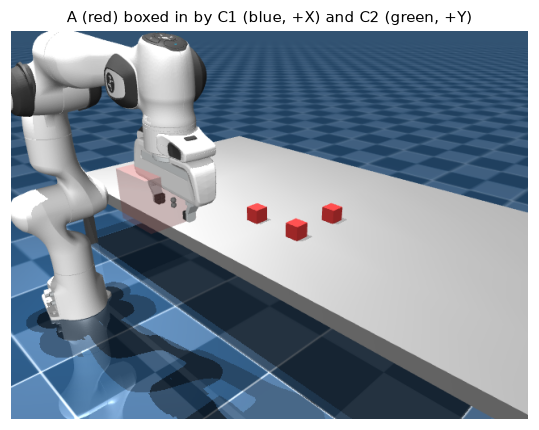

In [39]:
BLOCKS = ["block_0", "block_1", "block_2"]
BLOCK_HALF = env.get_object_half_size("block_0")
domain  = BlocksDomain(env.model, table_geom_name="table_surface")
BOUNDS  = domain.get_working_bounds()
TABLE_Z = BOUNDS["table_height"]
START = {"block_0": (0.500, 0.550), "block_1": (0.500, 0.400), "block_2": (0.350, 0.400)}
for n, (x, y) in START.items():
    env.set_object_pose(n, np.array([x, y, TABLE_Z + BLOCK_HALF[2] + 0.003]))
env.reset_velocities(); env.forward(); env.rest(0.4)
print(f"working area x ∈ [{BOUNDS['min_x']:.2f},{BOUNDS['max_x']:.2f}], "
      f"y ∈ [{BOUNDS['min_y']:.2f},{BOUNDS['max_y']:.2f}], table_z={TABLE_Z:.3f}")
show_scene(env, "A (red) boxed in by C1 (blue, +X) and C2 (green, +Y)")

In [56]:
bridge = DomainBridge("pddl/coarse/lego_coarse.pddl", env)
bridge.plan = functools.partial(type(bridge).plan, bridge, planner_name="pyperplan")

In [ ]:
# actually skip above and just use pddl like in ex 2
from unified_planning.io import PDDLReader
from unified_planning.shortcuts import OneshotPlanner

problem = PDDLReader().parse_problem("pddl/coarse/lego_coarse.pddl", "pddl/coarse/toy_stack_problem.pddl")
with OneshotPlanner(name='fast-downward', problem_kind=problem.kind) as planner:
    result = planner.solve(problem)
    result = bridge.plan(problem)
    # print(result.plan)

UPNoRequestedEngineAvailableException: 

In [ ]:
# actually skip above and just use pddl like in ex 2
from unified_planning.io import PDDLReader
from unified_planning.shortcuts import OneshotPlanner

problem = PDDLReader().parse_problem("pddl/coarse/lego_coarse.pddl", "pddl/coarse/toy_stack_problem.pddl")
with OneshotPlanner(name='fast-downward', problem_kind=problem.kind) as planner:
    result = planner.solve(problem)
    result = bridge.plan(problem)
    # print(result.plan)

UPNoRequestedEngineAvailableException: 